In [1]:
#library imports
import gcsfs
from google.cloud import storage
import pyarrow.parquet as pq
import pyarrow.fs as pafs
import pandas as pd
import tensorflow as tf
import open3d as o3d
import numpy as np


/home/jacob/projects/waymo_research/3d_semseg/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/home/jacob/projects/waymo_research/3d_semseg/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
I0000 00:00:1779

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
#get google cloud token
import os
os.environ["CLOUDSDK_CONFIG"] = "/home/jacob/.config/gcloud"

import subprocess
token = subprocess.check_output(
    ["/usr/bin/gcloud", "auth", "print-access-token"]
).decode().strip()

In [3]:
from datetime import datetime, timezone, timedelta
fs = pafs.GcsFileSystem(access_token=token, credential_token_expiration=datetime.now(timezone.utc) + timedelta(hours=1))

#list files in each folder
folders = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/"))
lidar_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar/"))
seg_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar_segmentation/"))
calib_files = fs.get_file_info(pafs.FileSelector("waymo_open_dataset_v_2_0_0/training/lidar_calibration/"))

for f in lidar_files[:3]:
    print(f.path)
for f in seg_files[:3]:
    print(f.path)
for f in calib_files[:3]:
    print(f.path)

waymo_open_dataset_v_2_0_0/training/lidar/10017090168044687777_6380_000_6400_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar/10023947602400723454_1120_000_1140_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar/1005081002024129653_5313_150_5333_150.parquet
waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10023947602400723454_1120_000_1140_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar_segmentation/1005081002024129653_5313_150_5333_150.parquet
waymo_open_dataset_v_2_0_0/training/lidar_calibration/10017090168044687777_6380_000_6400_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar_calibration/10023947602400723454_1120_000_1140_000.parquet
waymo_open_dataset_v_2_0_0/training/lidar_calibration/1005081002024129653_5313_150_5333_150.parquet


In [4]:
#sample lidar file loading to see contents
pf_lidar = pq.ParquetFile(lidar_files[0].path, filesystem=fs)
print("Number of row groups: ", pf_lidar.metadata.num_row_groups) 
print("Array of columns: ", pf_lidar.schema) 
# cols = ["key.frame_timestamp_micros", "[LiDARComponent].range_image_return1.tensor"]
rg = pf_lidar.read_row_group(0)
df = rg.to_pandas()
df.head()

Number of row groups:  4
Array of columns:  <pyarrow._parquet.ParquetSchema object at 0x78673ef3f4c0>
required group field_id=-1 schema {
  optional binary field_id=-1 index (String);
  optional binary field_id=-1 key.segment_context_name (String);
  optional int64 field_id=-1 key.frame_timestamp_micros;
  optional int32 field_id=-1 key.laser_name (Int(bitWidth=8, isSigned=true));
  optional group field_id=-1 [LiDARComponent].range_image_return1.values (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return1.shape (List) {
    repeated group field_id=-1 list {
      optional int32 field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return2.values (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 item;
    }
  }
  optional group field_id=-1 [LiDARComponent].range_image_return2.shape (List) {
    repeated group field_id=-

,key.segment_context_name,key.frame_timestamp_micros,key.laser_name,[LiDARComponent].range_image_return1.values,[LiDARComponent].range_image_return1.shape,[LiDARComponent].range_image_return2.values,[LiDARComponent].range_image_return2.shape
index,,,,,,,
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,1,"[20.885931, 0.19042969, 1.493107, -1.0, 18.936...","[64, 2650, 4]","[-1.0, -1.0, -1.0, -1.0, 21.003038, 0.14941406...","[64, 2650, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,2,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,3,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,4,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"
10017090168044687777_6380_000_6400_000;1550083467346370,10017090168044687777_6380_000_6400_000,1550083467346370,5,"[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]","[-1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1....","[200, 600, 4]"


In [5]:
pf_calib = pq.ParquetFile(calib_files[0].path, filesystem=fs)
rgc = pf_calib.read_row_group(0)
df_rgc = rgc.to_pandas()
df_rgc.head(5)

,key.segment_context_name,key.laser_name,[LiDARCalibrationComponent].extrinsic.transform,[LiDARCalibrationComponent].beam_inclination.min,[LiDARCalibrationComponent].beam_inclination.max,[LiDARCalibrationComponent].beam_inclination.values
0,10017090168044687777_6380_000_6400_000,2,"[0.999762602122432, 0.0036877475559088514, 0.0...",-1.570796,0.523599,None
1,10017090168044687777_6380_000_6400_000,5,"[-0.9997324974348434, -0.013945152838121559, -...",-1.570796,0.523599,None
2,10017090168044687777_6380_000_6400_000,3,"[0.013387855309090483, -0.9997985726737589, 0....",-1.570796,0.523599,None
3,10017090168044687777_6380_000_6400_000,4,"[-0.026661403897150483, 0.9996313994371858, 0....",-1.570796,0.523599,None
4,10017090168044687777_6380_000_6400_000,1,"[-0.8477724631263563, -0.5303541574199493, -0....",-0.314504,0.039886,"[-0.30925746832197243, -0.29876530723528183, -..."


### Decoding the range images (spherical coordinates) into point clouds (cartesian coordinates)


In [6]:
def sphere_to_cart(phi, rho, theta):
    horizontal_d = rho * np.cos(theta)
    X = horizontal_d * np.cos(phi)
    Y = horizontal_d * np.sin(phi)
    Z = rho * np.sin(theta)

    return X, Y, Z


laser_1_lidar = df.loc[df["key.laser_name"] == 1]
laser_1_lidar_t = laser_1_lidar.iloc[0]
#print(tuple(laser_1_lidar_t["[LiDARComponent].range_image_return1.shape"]))
#print(laser_1_lidar_t)

laser_1_lidar_t_grid = laser_1_lidar_t["[LiDARComponent].range_image_return1.values"].reshape(64, 2650, 4)
#print(laser_1_lidar_t_grid)


laser_1_calib = df_rgc.loc[df_rgc["key.laser_name"] == 1]
# extract the list of beam inclinations from the single row and convert to numpy array
theta_series = laser_1_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0]
theta_array = np.array(theta_series)
#print(theta_series)

phi_array = np.linspace(np.pi, np.pi * -1, num=2650)
#print(phi_array)

range_channel = laser_1_lidar_t_grid[:, :, 0]
ranges = range_channel[:, :]
range_mask = ranges > 0
print(range_mask)


[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


In [7]:
#apply to function

T_array, P_array = np.meshgrid(phi_array, theta_array)
# print(T_array)

X_unmasked, Y_unmasked, Z_unmasked = sphere_to_cart(P_array, range_channel, T_array)

X = X_unmasked[range_mask]
Y = Y_unmasked[range_mask]
Z = Z_unmasked[range_mask]

print("X: ", X)
print("Y: ", Y)
print("Z: ", Z)

X:  [-19.89509875 -18.03772642 -19.66062203 ...  -5.37526489  -5.63254863
  -5.77241344]
Y:  [ 6.35666265  5.76321551  6.28174523 ... -0.2069911  -0.2168986
 -0.22228453]
Z:  [ 2.55778886e-15  4.49146749e-02  9.79120532e-02 ... -2.38582871e+00
 -2.48404189e+00 -2.52937875e+00]


Using the extrensic transformation data to make the cartesian points global relative to the scene, instead of local

In [8]:
ex_transform_df= laser_1_calib["[LiDARCalibrationComponent].extrinsic.transform"].iloc[0]
ex_transform = np.array((ex_transform_df)).reshape(4, 4)
print(ex_transform)

points = np.column_stack((X, Y, Z))
homo_coords = np.column_stack((points, np.ones(len(X))))
print(points.shape)

homo_coords_T = np.transpose(homo_coords)
global_coords_T = np.dot(ex_transform, homo_coords_T)
global_coords_1 = np.transpose(global_coords_T)

#drop 4th column
global_coords = global_coords_1[:, :3]

[[-8.47772463e-01 -5.30354157e-01 -2.51365711e-03  1.43000000e+00]
 [ 5.30355440e-01 -8.47775368e-01  1.80144262e-04  0.00000000e+00]
 [-2.22655684e-03 -1.18041038e-03  9.99996825e-01  2.18400000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
(153830, 3)


Loading the labels

In [9]:
pf_seg = pq.ParquetFile(seg_files[0].path, filesystem=fs)
seg = pf_seg.read_row_group(0)
df_seg = seg.to_pandas()
df_seg.head()

,key.segment_context_name,key.frame_timestamp_micros,key.laser_name,[LiDARSegmentationLabelComponent].range_image_return1.values,[LiDARSegmentationLabelComponent].range_image_return1.shape,[LiDARSegmentationLabelComponent].range_image_return2.values,[LiDARSegmentationLabelComponent].range_image_return2.shape
index,,,,,,,
10017090168044687777_6380_000_6400_000;1550083469745187,10017090168044687777_6380_000_6400_000,1550083469745187,1,"[-1, 21, -1, 15, -1, 15, -1, 21, -1, 21, 0, 0,...","[64, 2650, 2]","[-1, 15, -1, 15, -1, 15, 0, 0, 0, 0, 0, 0, -1,...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083470245288,10017090168044687777_6380_000_6400_000,1550083470245288,1,"[-1, 17, -1, 17, -1, 17, -1, 17, -1, 21, -1, 2...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083470745363,10017090168044687777_6380_000_6400_000,1550083470745363,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083471245613,10017090168044687777_6380_000_6400_000,1550083471245613,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"
10017090168044687777_6380_000_6400_000;1550083471746058,10017090168044687777_6380_000_6400_000,1550083471746058,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[64, 2650, 2]"


In [10]:
laser_1_seg = df_seg.loc[df_seg["key.laser_name"] == 1]
laser_1_seg_t = laser_1_seg.iloc[0]
#print(laser_1_seg_t)

laser_1_seg_t_grid = laser_1_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.values"].reshape(64, 2650, 2)
print(laser_1_lidar_t_grid[0])

[[ 2.0885931e+01  1.9042969e-01  1.4931070e+00 -1.0000000e+00]
 [ 1.8936110e+01  3.5888672e-02  7.6119177e-02 -1.0000000e+00]
 [ 2.0640009e+01  1.6308594e-01  9.3099612e-01 -1.0000000e+00]
 ...
 [ 1.9568483e+01  2.2363281e-01  1.1710643e-01 -1.0000000e+00]
 [ 1.5756670e+01  1.0681152e-02  8.1974499e-02 -1.0000000e+00]
 [ 2.0973761e+01  1.4062500e-01  8.9000887e-01 -1.0000000e+00]]


In [11]:
seg_grid_masked = laser_1_seg_t_grid[range_mask]
seg_grid_masked_coords = seg_grid_masked[:, 1]

print(seg_grid_masked_coords)


[21 15 15 ... 15 15 15]


Creating Functions for these methods to apply them to all LiDAR lasers

In [12]:
#processing each lidar laser for a given timestamp

def laser_process(laser_num: int, df, df_rgc, df_seg, timestamp):

    #df == lidar folder (range image points)
    #df_rgc == calibration folder (angle of each lidar sensor)
    #df_seg == segmentation class labels


    #lidar folder processing
    laser_lidar = df.loc[df["key.laser_name"] == int(laser_num)]
    laser_lidar_t = laser_lidar.loc[laser_lidar["key.frame_timestamp_micros"] == timestamp]
    laser_shape = tuple(laser_lidar_t["[LiDARComponent].range_image_return1.shape"].iloc[0])
    laser_lidar_t_grid = laser_lidar_t["[LiDARComponent].range_image_return1.values"].iloc[0].reshape(laser_shape)

    #calibration folder processing
    laser_calib = df_rgc.loc[df_rgc["key.laser_name"] == int(laser_num)]

    if laser_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0] is not None:
        theta_series = laser_calib["[LiDARCalibrationComponent].beam_inclination.values"].iloc[0]

    else:
        max_inclin = laser_calib["[LiDARCalibrationComponent].beam_inclination.max"].iloc[0]
        min_inclin = laser_calib["[LiDARCalibrationComponent].beam_inclination.min"].iloc[0]
        theta_series = np.linspace(max_inclin, min_inclin, num=laser_shape[0])
    
    #converting to cartesian from spherical range image
    theta_array = np.array(theta_series)
    phi_array = np.linspace(np.pi, np.pi * -1, num=laser_shape[1])

    #range channel / masking
    range_channel = laser_lidar_t_grid[:, :, 0]
    ranges = range_channel[:, :]
    range_mask = ranges > 0

    Theta_array, Phi_array = np.meshgrid(phi_array, theta_array)

    X_unmasked, Y_unmasked, Z_unmasked = sphere_to_cart(Phi_array, range_channel, Theta_array)

    X = X_unmasked[range_mask]
    Y = Y_unmasked[range_mask]
    Z = Z_unmasked[range_mask]
    
    #extrinsic transformation (to make it global relative to the scene instead of the sensor)
    ex_transform_df= laser_calib["[LiDARCalibrationComponent].extrinsic.transform"].iloc[0]
    ex_transform = np.array((ex_transform_df)).reshape(4, 4)

    points = np.column_stack((X, Y, Z))
    homo_coords = np.column_stack((points, np.ones(len(X))))

    homo_coords_T = np.transpose(homo_coords)
    global_coords_T = np.dot(ex_transform, homo_coords_T)
    global_coords_1 = np.transpose(global_coords_T)

    #drop 4th column to get the global X, Y, Z coords
    global_coords = global_coords_1[:, :3]

    #process segmentation labels 
    laser_seg = df_seg.loc[df_seg["key.laser_name"] == int(laser_num)]
    if not laser_seg.empty:
        laser_seg_t = laser_seg.loc[laser_seg["key.frame_timestamp_micros"] == timestamp]
        if laser_seg_t.empty:
            return global_coords, np.zeros(len(global_coords), dtype=int)
    else: 
        return global_coords, np.zeros(len(global_coords), dtype=int) 
    seg_shape = tuple(laser_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.shape"].iloc[0])
    laser_seg_t_grid = laser_seg_t["[LiDARSegmentationLabelComponent].range_image_return1.values"].iloc[0].reshape(seg_shape)
    
    #mask the seg grid to get the true segmentation labels of each X, Y, Z
    seg_grid_masked = laser_seg_t_grid[range_mask]
    seg_grid_masked_coords = seg_grid_masked[:, 1]

    return global_coords, seg_grid_masked_coords


In [13]:
#testing the function

g_coords, masked_labels = laser_process(laser_num=4, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=1550083471245613)
print("Global coords: ", global_coords)
print("Segmented labels: ", masked_labels)
df_seg["key.frame_timestamp_micros"].unique()

Global coords:  [[ 14.92523441 -15.94049588   2.2207941 ]
 [ 13.66522954 -14.4523104    2.2622736 ]
 [ 14.76593815 -15.75260909   2.3182722 ]
 ...
 [  6.10277731  -2.67574882  -0.18960846]
 [  6.32639673  -2.803819    -0.28723679]
 [  6.44794068  -2.87343918  -0.33225573]]
Segmented labels:  [0 0 0 ... 0 0 0]


array([1550083469745187, 1550083470245288, 1550083470745363,
       1550083471245613, 1550083471746058, 1550083472246691,
       1550083472747311, 1550083473247979, 1550083473748639,
       1550083474248852, 1550083474748923, 1550083475249048,
       1550083475749061, 1550083476248935, 1550083476748941,
       1550083477248893, 1550083477748939, 1550083478248969,
       1550083478748949, 1550083479248954, 1550083479749007,
       1550083480249090, 1550083480749230, 1550083481248979,
       1550083481748694, 1550083482248377, 1550083482748439,
       1550083483248542, 1550083483748615, 1550083484248678])

Using Open3D to visualize these points and their classes

In [14]:
#fusing the lasers, even though 2-5 aren't capturing any semantic classes, for this timestep at least

g_coords_1, masked_labels_1 = laser_process(laser_num=1, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=laser_1_lidar_t["key.frame_timestamp_micros"])
g_coords_2, masked_labels_2 = laser_process(laser_num=2, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=laser_1_lidar_t["key.frame_timestamp_micros"])
g_coords_3, masked_labels_3 = laser_process(laser_num=3, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=laser_1_lidar_t["key.frame_timestamp_micros"])
g_coords_4, masked_labels_4 = laser_process(laser_num=4, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=laser_1_lidar_t["key.frame_timestamp_micros"])
g_coords_5, masked_labels_5 = laser_process(laser_num=5, df=df, df_rgc=df_rgc, df_seg=df_seg, timestamp=laser_1_lidar_t["key.frame_timestamp_micros"])

g_coords_concat = np.concatenate((g_coords_1, g_coords_2, g_coords_3, g_coords_4, g_coords_5))
masked_labels_concat = np.concatenate((masked_labels_1, masked_labels_2, masked_labels_3, masked_labels_4, masked_labels_5))

#mapping classes to labels
labels = np.unique(masked_labels_1)

kelly_colors = [
    "#444444", "#F2F3F4", "#222222", "#F3C300", "#875692", "#F38400", "#A1CAF1", "#BE0032", 
    "#C2B280", "#848482", "#008856", "#E68FAC", "#0067A5", "#F99379", "#604E97", 
    "#F6A600", "#B3446C", "#DCD300", "#882D17", "#8DB600", "#654522", "#E25822", "#2B3D26"
]

label_indexes = [i for i in range(23)]
mapping = dict(zip(label_indexes, kelly_colors))

#convert to hex for open3d viewing
def hex_to_rgb01(hex_str):                      
    h = hex_str.lstrip('#')                            
    return [int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4)]

rgb_colors = np.array([hex_to_rgb01(mapping.get(int(lbl), '#444444')) for lbl in masked_labels_concat])

#open3d visualizing - will do later, WSL issues
# pcd = o3d.geometry.PointCloud()
# pcd.points = o3d.utility.Vector3dVector(g_coords_concat.astype(np.float64))
# pcd.colors = o3d.utility.Vector3dVector(rgb_colors)

# o3d.visualization.draw([pcd])



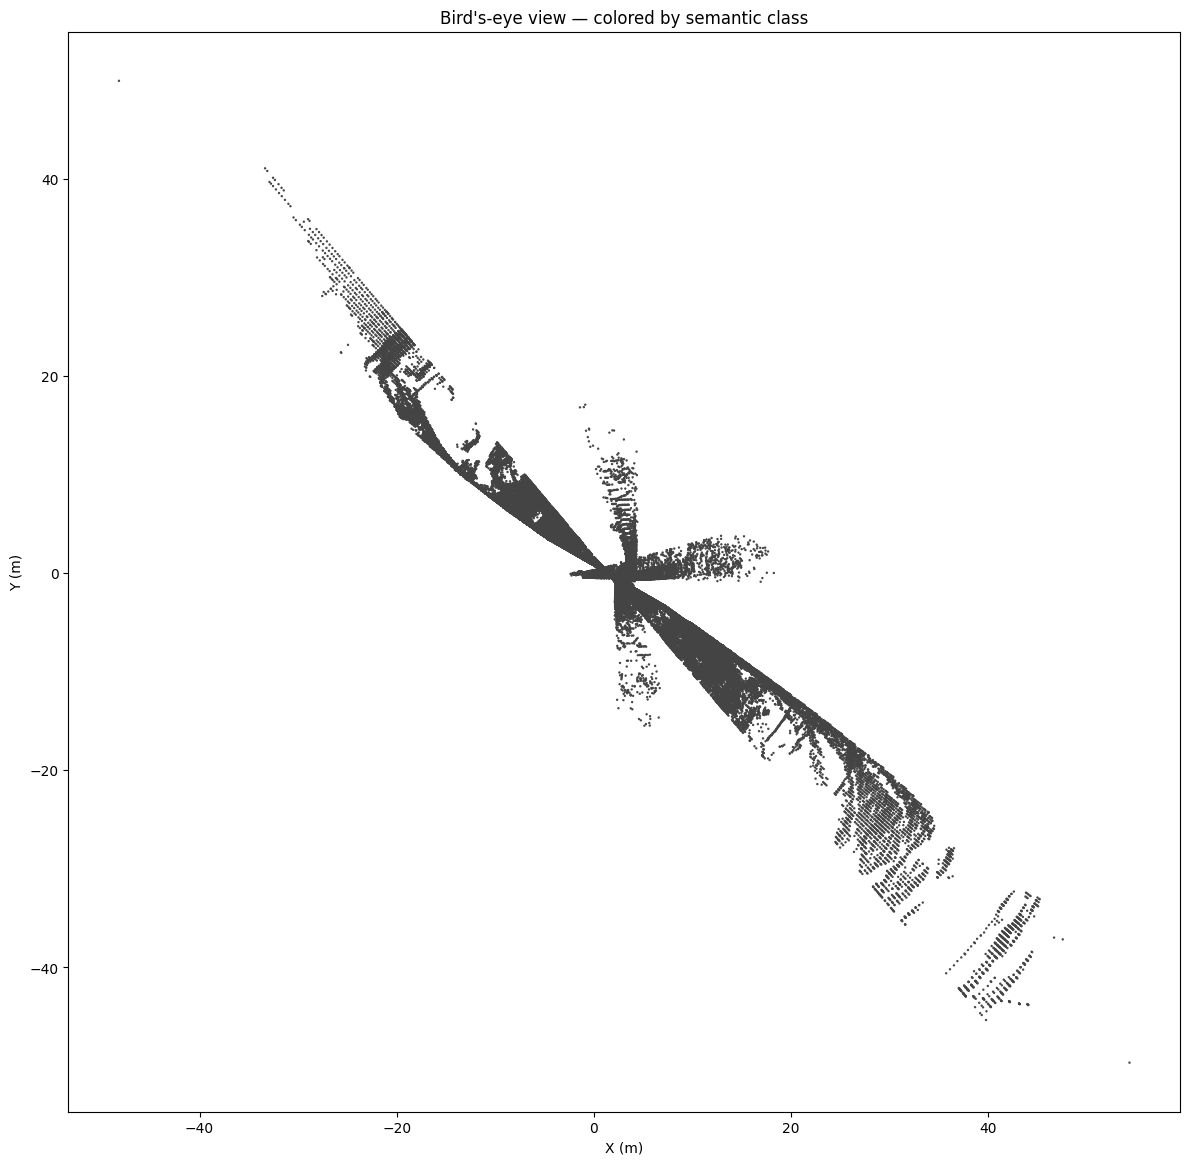

In [15]:
import matplotlib.pyplot as plt

point_colors = [mapping.get(int(lbl), '#444444') for lbl in masked_labels_concat]

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(g_coords_concat[:, 0], g_coords_concat[:, 1], c=point_colors, s=0.5)
ax.set_aspect('equal')
ax.set_title("Bird's-eye view — colored by semantic class")
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.tight_layout()
plt.show()


This image looks strange because of it being only 200ms of LiDAR, so it is sparse (and I have realized that the timestamps don't line up in the same order for the lidar/ and lidar_segmentation/ folders, which explains the lack of color and segmented classes).

Building the DataLoader to visualize more scenes, correctly.

In [16]:
#creating index mapping of lidar files and timestamps

def folder_file_indexer(folder):
    file_timestamp_index = []
    lidar_files = fs.get_file_info(pafs.FileSelector(f"waymo_open_dataset_v_2_0_0/{folder}"))
    for i in range(len(lidar_files[:10])):  #only first 10 files
        pf_lidar = pq.ParquetFile(lidar_files[i].path, filesystem=fs)
        for j in range(pf_lidar.num_row_groups):

            rg = pf_lidar.read_row_group(j, columns=["key.frame_timestamp_micros"])
            df_idx = rg.to_pandas()

            for stamp in df_idx["key.frame_timestamp_micros"].unique():
                index_file_pair = tuple((lidar_files[i].path, stamp))
                file_timestamp_index.append(index_file_pair)


    return file_timestamp_index

seg_timestamp_index = folder_file_indexer(folder="training/lidar_segmentation/")
print(seg_timestamp_index)
lidar_timestamp_index = folder_file_indexer(folder="training/lidar/")
print(lidar_timestamp_index)

[('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083469745187)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083470245288)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083470745363)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083471245613)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083471746058)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083472246691)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentation/10017090168044687777_6380_000_6400_000.parquet', np.int64(1550083472747311)), ('waymo_open_dataset_v_2_0_0/training/lidar_segmentati

In [17]:
#dataframe function to fetch row groups with the same timestamp between files (lidar and seg)

def timestamp_aligner(file_path, timestamp):
    file_pq = pq.ParquetFile(file_path, filesystem=fs)
    for i in range(file_pq.num_row_groups):
        rg_time = file_pq.read_row_group(i, columns=["key.frame_timestamp_micros"])
        df_time = rg_time.to_pandas()
        if df_time["key.frame_timestamp_micros"].isin([timestamp]).any():
            rg_all = file_pq.read_row_group(i)
            df_all = rg_all.to_pandas()
            return df_all

seg_test_file, seg_test_timestamp = seg_timestamp_index[0]
for tup in lidar_timestamp_index:
    if seg_test_timestamp in tup:
        lidar_test_file, lidar_test_timestamp = tup
        lidar_test_df = timestamp_aligner(lidar_test_file, lidar_test_timestamp)
        seg_test_df = timestamp_aligner(seg_test_file, seg_test_timestamp)
        break


print(lidar_test_df.info())
print(seg_test_df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 256 entries, 10017090168044687777_6380_000_6400_000;1550083467346370 to 10017090168044687777_6380_000_6400_000;1550083472446914
Data columns (total 7 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   key.segment_context_name                     256 non-null    object
 1   key.frame_timestamp_micros                   256 non-null    int64 
 2   key.laser_name                               256 non-null    int8  
 3   [LiDARComponent].range_image_return1.values  256 non-null    object
 4   [LiDARComponent].range_image_return1.shape   256 non-null    object
 5   [LiDARComponent].range_image_return2.values  256 non-null    object
 6   [LiDARComponent].range_image_return2.shape   256 non-null    object
dtypes: int64(1), int8(1), object(5)
memory usage: 14.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1001709016804468

Now we can wire these functions together

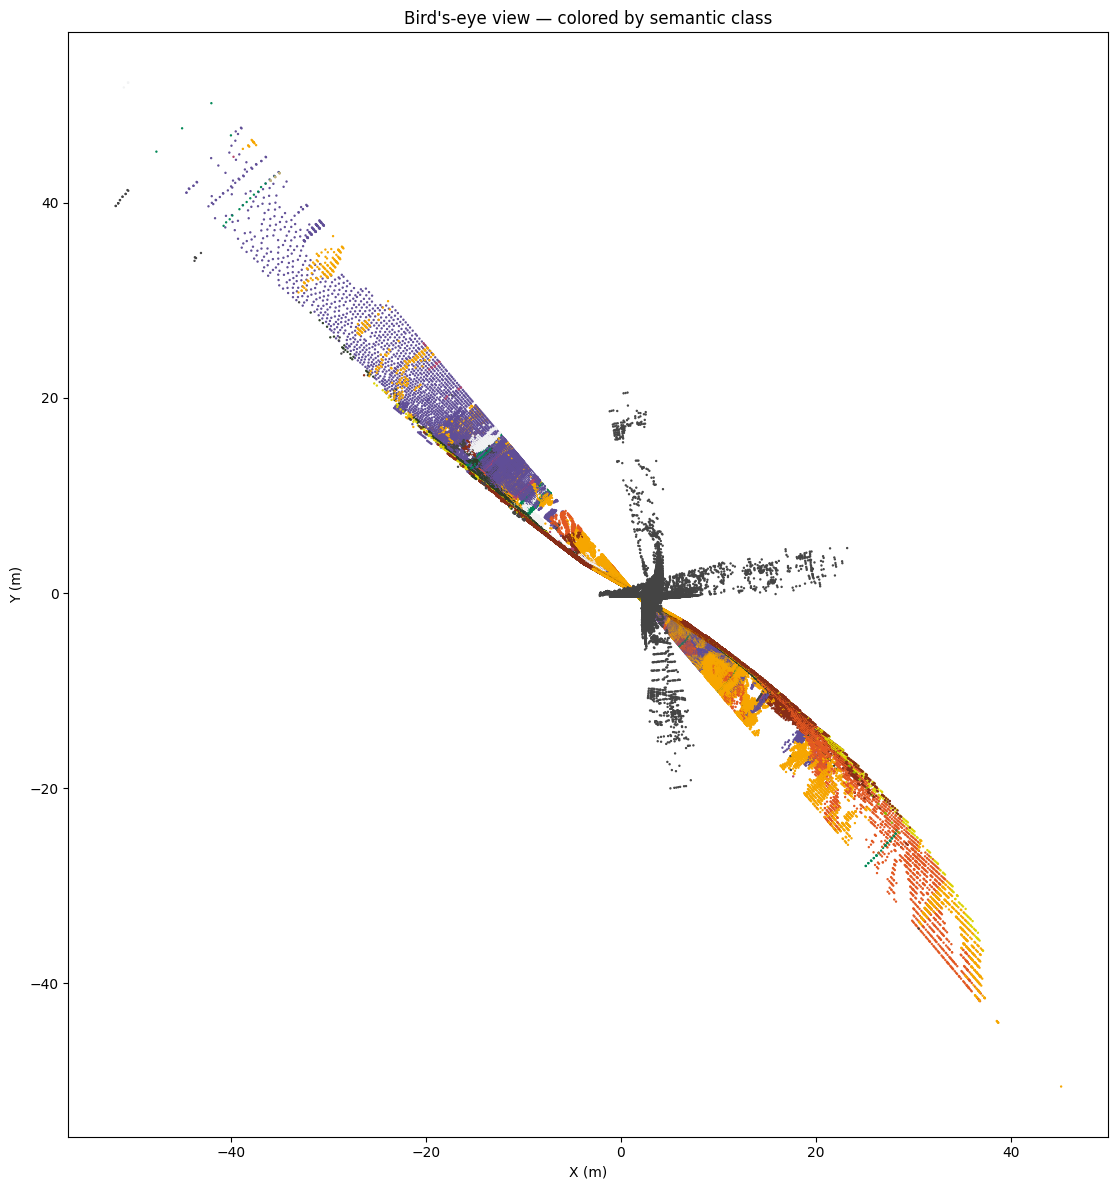

: 

In [ ]:
#call the calibration file for a specific file

base_file = os.path.basename(seg_test_file)
calib_test_file = pq.ParquetFile(f"waymo_open_dataset_v_2_0_0/training/lidar_calibration/{base_file}", filesystem=fs)
calib_test_rq = calib_test_file.read_row_group(0)
calib_test_df = calib_test_rq.to_pandas()

#calling laser processes
g_coords_1, masked_labels_1 = laser_process(laser_num=1, df=lidar_test_df, df_rgc=calib_test_df, df_seg=seg_test_df, timestamp=seg_test_timestamp)
g_coords_2, masked_labels_2 = laser_process(laser_num=2, df=lidar_test_df, df_rgc=calib_test_df, df_seg=seg_test_df, timestamp=seg_test_timestamp)
g_coords_3, masked_labels_3 = laser_process(laser_num=3, df=lidar_test_df, df_rgc=calib_test_df, df_seg=seg_test_df, timestamp=seg_test_timestamp)
g_coords_4, masked_labels_4 = laser_process(laser_num=4, df=lidar_test_df, df_rgc=calib_test_df, df_seg=seg_test_df, timestamp=seg_test_timestamp)
g_coords_5, masked_labels_5 = laser_process(laser_num=5, df=lidar_test_df, df_rgc=calib_test_df, df_seg=seg_test_df, timestamp=seg_test_timestamp)

#fusing
g_coords_concat = np.concatenate((g_coords_1, g_coords_2, g_coords_3, g_coords_4, g_coords_5))
masked_labels_concat = np.concatenate((masked_labels_1, masked_labels_2, masked_labels_3, masked_labels_4, masked_labels_5))

#plotting
point_colors = [mapping.get(int(lbl), '#444444') for lbl in masked_labels_concat]

fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(g_coords_concat[:, 0], g_coords_concat[:, 1], c=point_colors, s=0.5)
ax.set_aspect('equal')
ax.set_title("Bird's-eye view — colored by semantic class")
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
plt.tight_layout()
plt.show()


Successfully visualized a frame of lidar with corresponding timestamps.

Next: Visualize multiple frames from a segment to create a sequence / full image.

In [ ]:
#matching row groups of timestamps as a whole between lidar and seg files instead of just timestamps
#allows us to retrieve multiple frames efficiently

def scene_processor(scene_base_path):
    lidar_scene_animation = []

    seg_file_path = os.path.join(os.path.dirname(seg_timestamp_index[0][0]), scene_base_path)
    lidar_file_path = os.path.join(os.path.dirname(lidar_timestamp_index[0][0]), scene_base_path)
    
    calib_test_file = pq.ParquetFile(f"waymo_open_dataset_v_2_0_0/training/lidar_calibration/{scene_base_path}", filesystem=fs)
    calib_test_df = calib_test_file.read_row_group(0).to_pandas()

    seg_pq = pq.ParquetFile(seg_file_path, filesystem=fs)
    lidar_pq = pq.ParquetFile(lidar_file_path, filesystem=fs)

    for i in range(seg_pq.num_row_groups):

        seg_df = seg_pq.read_row_group(i).to_pandas()
        rg_t_1 = seg_df["key.frame_timestamp_micros"].iloc[0]
        lidar_df = None

        for j in range(lidar_pq.num_row_groups):
            lidar_times = lidar_pq.read_row_group(j, columns="key.frame_timestamp_micros").to_pandas()
            if lidar_times["key.frame_timestamp_micros"].isin([rg_t_1]).any():
                lidar_df = lidar_pq.read_row_group(j).to_pandas()
                break

        if lidar_df is None:
            continue

        for timestamp in seg_df["key.frame_timestamp_micros"].unique():
            g_coords_1, masked_labels_1 = laser_process(laser_num=1, df=lidar_df, df_rgc=calib_test_df, df_seg=seg_df, timestamp=timestamp)
            g_coords_2, masked_labels_2 = laser_process(laser_num=2, df=lidar_df, df_rgc=calib_test_df, df_seg=seg_df, timestamp=timestamp)
            g_coords_3, masked_labels_3 = laser_process(laser_num=3, df=lidar_df, df_rgc=calib_test_df, df_seg=seg_df, timestamp=timestamp)
            g_coords_4, masked_labels_4 = laser_process(laser_num=4, df=lidar_df, df_rgc=calib_test_df, df_seg=seg_df, timestamp=timestamp)
            g_coords_5, masked_labels_5 = laser_process(laser_num=5, df=lidar_df, df_rgc=calib_test_df, df_seg=seg_df, timestamp=timestamp)

            g_coords_concat = np.concatenate((g_coords_1, g_coords_2, g_coords_3, g_coords_4, g_coords_5))
            masked_labels_concat = np.concatenate((masked_labels_1, masked_labels_2, masked_labels_3, masked_labels_4, masked_labels_5))

            lidar_scene_animation.append((g_coords_concat, masked_labels_concat))

    return lidar_scene_animation

In [ ]:
#drawing the animation

import matplotlib.animation as animation
from IPython.display import HTML

# fix axis limits across all frames so the view doesn't jump
all_x = np.concatenate([f[0][:, 0] for f in animation_frame_list])
all_y = np.concatenate([f[0][:, 1] for f in animation_frame_list])
x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_aspect('equal')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')

# initialise scatter with first frame
coords0, labels0 = animation_frame_list[0]
colors0 = [mapping.get(int(lbl), '#444444') for lbl in labels0]
scat = ax.scatter(coords0[:, 0], coords0[:, 1], c=colors0, s=0.5)
title = ax.set_title(f"Frame 0 / {len(animation_frame_list) - 1}")

def update(frame_idx):
    coords, labels = animation_frame_list[frame_idx]
    colors = [mapping.get(int(lbl), '#444444') for lbl in labels]
    scat.set_offsets(coords[:, :2])
    scat.set_facecolor(colors)
    title.set_text(f"Frame {frame_idx} / {len(animation_frame_list) - 1}")
    return scat, title

anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(animation_frame_list),
    interval=100,  # 100 ms ≈ 10 Hz, matching Waymo capture rate
    blit=True,
)

plt.close(fig)  # suppress static plot alongside the animation
HTML(anim.to_jshtml())